In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid")

train = pd.read_csv("../data/processed/train.csv").dropna()
test = pd.read_csv("../data/processed/test.csv").dropna()

X_train, y_train = train["text_clean"], train["label"]
X_test, y_test = test["text_clean"], test["label"]
print(X_train.shape, X_test.shape)

(23812,) (5954,)


In [2]:
def evaluer(nom, pipe, fichier_image, cv_folds=5):
    debut = time.time()
    pipe.fit(X_train, y_train)
    temps = time.time() - debut
    print(f"Temps d'entraînement : {temps:.2f} s\n")

    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rap = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"Accuracy  : {acc:.4f}")
    print(f"Précision : {prec:.4f}")
    print(f"Rappel    : {rap:.4f}")
    print(f"F1-score  : {f1:.4f}\n")
    print(classification_report(y_test, y_pred, target_names=["Non-spam", "Spam"], digits=4))

    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    ConfusionMatrixDisplay(cm, display_labels=["Non-spam", "Spam"]).plot(ax=ax, cmap="Blues", values_format="d")
    ax.set_title(f"Matrice de confusion : {nom}")
    ax.grid(False)
    plt.tight_layout()
    plt.savefig(fichier_image, dpi=150)
    plt.show()
    tn, fp, fn, tp = cm.ravel()
    print(f"Faux positifs : {fp} | Faux négatifs : {fn}\n")

    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1")
    print("F1 par pli :", scores.round(4))
    print(f"F1 moyen : {scores.mean():.4f} (± {scores.std():.4f})")

    ligne = {"modèle": nom, "accuracy": acc, "précision": prec, "rappel": rap, "f1": f1,
             "faux_positifs": int(fp), "faux_négatifs": int(fn),
             "f1_validation_croisée": scores.mean(), "temps_entraînement_s": round(temps, 2)}
    chemin = "../data/processed/resultats.csv"
    res = pd.read_csv(chemin) if os.path.exists(chemin) else pd.DataFrame()
    if len(res) > 0:
        res = res[res["modèle"] != nom]
    res = pd.concat([res, pd.DataFrame([ligne])], ignore_index=True)
    res.to_csv(chemin, index=False)
    return pipe

Temps d'entraînement : 3.94 s

Accuracy  : 0.9903
Précision : 0.9837
Rappel    : 0.9957
F1-score  : 0.9897

              precision    recall  f1-score   support

    Non-spam     0.9962    0.9854    0.9908      3159
        Spam     0.9837    0.9957    0.9897      2795

    accuracy                         0.9903      5954
   macro avg     0.9899    0.9906    0.9902      5954
weighted avg     0.9903    0.9903    0.9903      5954



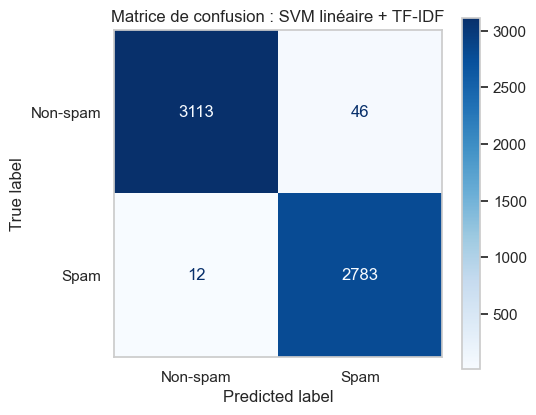

Faux positifs : 46 | Faux négatifs : 12

F1 par pli : [0.9891 0.9895 0.99   0.9902 0.9906]
F1 moyen : 0.9899 (± 0.0005)


In [3]:
pipe_svm = Pipeline([
    ("tfidf", TfidfVectorizer(min_df=3, max_df=0.95, max_features=50000)),
    ("svm", LinearSVC(C=1.0, random_state=42))
])
pipe_svm = evaluer("SVM linéaire + TF-IDF", pipe_svm, "../images/06_matrice_confusion_svm.png")

In [4]:
vocab = np.array(pipe_svm.named_steps["tfidf"].get_feature_names_out())
coef = pipe_svm.named_steps["svm"].coef_[0]
ordre = coef.argsort()

print("Mots poussant vers SPAM :")
print(list(vocab[ordre[::-1][:20]]))
print("\nMots poussant vers NON-SPAM :")
print(list(vocab[ordre[:20]]))

Mots poussant vers SPAM :
['mobile', 'remove', 'software', 'account', 'money', 'http', 'sir', 'hello', 'meds', 'low', 'site', 'investment', 'php', 'life', 'email', 'paliourg', 'future', 'goodbye', 'ra', 'viagra']

Mots poussant vers NON-SPAM :
['enron', 'vince', 'louise', 'thanks', 'attached', 'daren', 'employees', 'doc', 'energy', 'dave', 'questions', 'houston', 'monday', 'meeting', 'jim', 'listbot', 'please', 'hotmail', 'sally', 'know']


Temps d'entraînement : 11.90 s

Accuracy  : 0.9851
Précision : 0.9771
Rappel    : 0.9914
F1-score  : 0.9842

              precision    recall  f1-score   support

    Non-spam     0.9923    0.9794    0.9858      3159
        Spam     0.9771    0.9914    0.9842      2795

    accuracy                         0.9851      5954
   macro avg     0.9847    0.9854    0.9850      5954
weighted avg     0.9852    0.9851    0.9851      5954



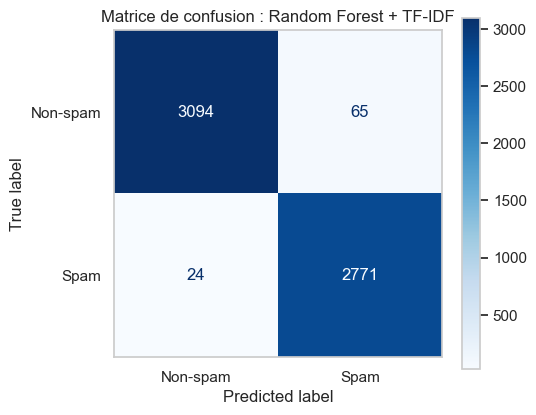

Faux positifs : 65 | Faux négatifs : 24

F1 par pli : [0.9835 0.9858 0.9827 0.9838 0.9853]
F1 moyen : 0.9842 (± 0.0011)


In [5]:
pipe_rf = Pipeline([
    ("tfidf", TfidfVectorizer(min_df=3, max_df=0.95, max_features=50000)),
    ("rf", RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42))
])
pipe_rf = evaluer("Random Forest + TF-IDF", pipe_rf, "../images/06_matrice_confusion_rf.png")

In [6]:
vocab = np.array(pipe_rf.named_steps["tfidf"].get_feature_names_out())
imp = pipe_rf.named_steps["rf"].feature_importances_
top = imp.argsort()[::-1][:20]

pd.DataFrame({"mot": vocab[top], "importance": imp[top].round(4)})

,mot,importance
0,enron,0.0326
1,http,0.0146
2,cc,0.0133
3,subject,0.0130
4,thanks,0.0128
5,pm,0.0116
6,attached,0.0110
7,vince,0.0105
8,nombre,0.0093
9,please,0.0093


In [7]:
pd.read_csv("../data/processed/resultats.csv").round(4)

,modèle,accuracy,précision,rappel,f1,faux_positifs,faux_négatifs,f1_validation_croisée,temps_entraînement_s
0,Naive Bayes + TF-IDF,0.9871,0.9885,0.9839,0.9862,32,45,0.9850,4.40
1,SVM linéaire + TF-IDF,0.9903,0.9837,0.9957,0.9897,46,12,0.9899,3.94
2,Random Forest + TF-IDF,0.9851,0.9771,0.9914,0.9842,65,24,0.9842,11.90


In [8]:
pd.read_csv("../data/processed/resultats.csv").round(4)

,modèle,accuracy,précision,rappel,f1,faux_positifs,faux_négatifs,f1_validation_croisée,temps_entraînement_s
0,Naive Bayes + TF-IDF,0.9871,0.9885,0.9839,0.9862,32,45,0.9850,4.40
1,SVM linéaire + TF-IDF,0.9903,0.9837,0.9957,0.9897,46,12,0.9899,3.94
2,Random Forest + TF-IDF,0.9851,0.9771,0.9914,0.9842,65,24,0.9842,11.90


In [11]:
git add notebooks_06_svm_random_forest.ipynb images/
git commit -m "Modeles SVM lineaire et Random Forest"

SyntaxError: invalid syntax (809242350.py, line 1)